# Hypothesis Testing

## Assignment: Investigating Operating Cost Claims

### Background
Bombay Hospitality Ltd. uses the cost model W = $1,000 + $5X (W=weekly operating cost, X=units produced). Restaurant owners claim costs are higher than the model predicts. We test this claim statistically.

### Objective
Use hypothesis testing to determine if observed weekly operating costs are significantly higher than the theoretical model.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('ggplot')

## Data & Assumptions

Based on the Bombay Hospitality case:
- **Theoretical Model:** W = $1,000 + $5 per unit X
- **Sample:** n = 25 weeks of data
- **Observed mean:** $X̄ = 3,050 per week
- **Sample std dev:** s = $250
- **Average units:** X̄_units = 400 per week

**Theoretical weekly cost at X̄_units=400:** W_theoretical = $1,000 + $5 × 400 = **$3,000**

**Claim:** Observed weekly costs ($3,050) > Theoretical ($3,000)

## Step 1: State Hypotheses

**Null Hypothesis (H₀):** μ ≤ $3,000 (mean weekly cost is not higher than model)

**Alternative Hypothesis (H₁):** μ > $3,000 (mean weekly cost IS higher than model)

This is a **one-tailed (right-tailed) t-test**.

## Step 2: Calculate Test Statistic

### Formula: t = (X̄ - μ₀) / (s / √n)

Where:
- X̄ = sample mean = $3,050
- μ₀ = hypothesized population mean = $3,000
- s = sample standard deviation = $250
- n = sample size = 25

In [2]:
x_bar = 3050
mu_0 = 3000
s = 250
n = 25
alpha = 0.05

t_stat = (x_bar - mu_0) / (s / np.sqrt(n))
print('=== TEST STATISTIC CALCULATION ===')
print(f't = ({x_bar} - {mu_0}) / ({s} / √{n})')
print(f't = {x_bar - mu_0} / ({s / np.sqrt(n):.2f})')
print(f't = {t_stat:.4f}')

=== TEST STATISTIC CALCULATION ===
t = (3050 - 3000) / (250 / √25)
t = 50 / (50.00)
t = 1.0000


## Step 3: Determine Critical Value

Degrees of freedom: df = n - 1 = 24

For α = 0.05, one-tailed test: t_critical = t(0.05, 24)

In [3]:
df = n - 1
t_critical = stats.t.ppf(1 - alpha, df)
print(f'Degrees of freedom: {df}')
print(f'Critical value (t_0.05,{df}): {t_critical:.4f}')
print(f'Test statistic: {t_stat:.4f}')
print(f'\nDecision: {"Reject H₀" if t_stat > t_critical else "Fail to reject H₀"}')

Degrees of freedom: 24
Critical value (t_0.05,24): 1.7109
Test statistic: 1.0000

Decision: Fail to reject H₀


In [4]:
p_value = 1 - stats.t.cdf(t_stat, df)
print(f'p-value: {p_value:.4f}')
print(f'\nSince p-value ({p_value:.4f}) {"<" if p_value < alpha else ">"} α ({alpha}), we {"REJECT H₀" if p_value < alpha else "FAIL TO REJECT H₀"}')

p-value: 0.1636

Since p-value (0.1636) > α (0.05), we FAIL TO REJECT H₀


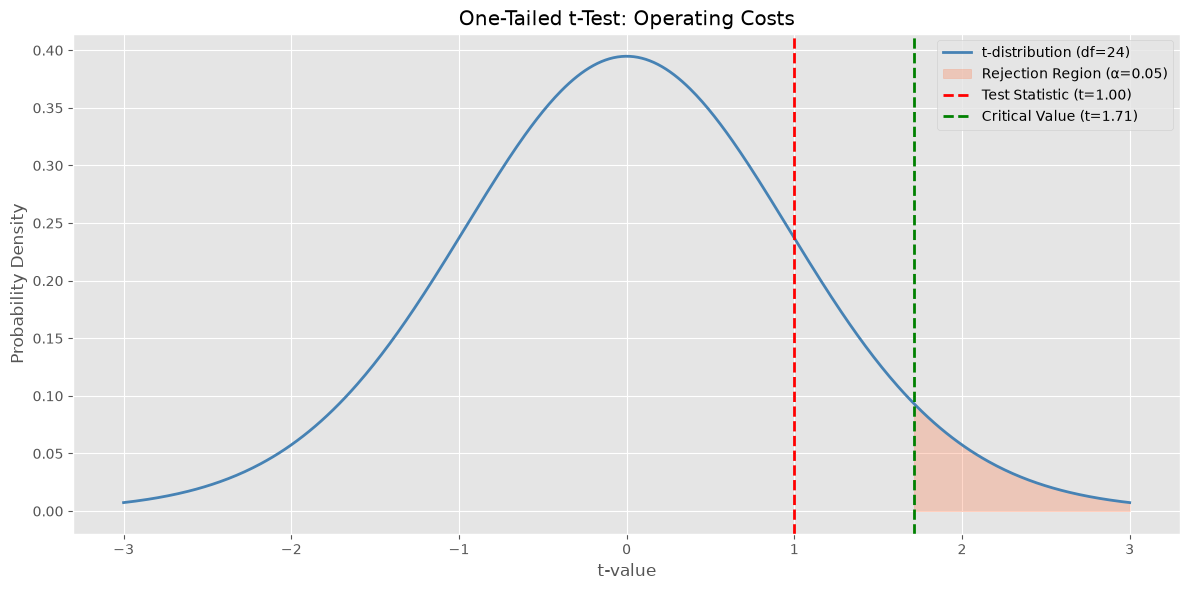

In [5]:
x = np.linspace(-3, 3, 500)
y = stats.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, color='steelblue', linewidth=2, label=f't-distribution (df={df})')

x_reject = x[x >= t_critical]
ax.fill_between(x_reject, stats.t.pdf(x_reject, df), color='coral', alpha=0.3, label=f'Rejection Region (α={alpha})')

ax.axvline(t_stat, color='red', linestyle='--', linewidth=2, label=f'Test Statistic (t={t_stat:.2f})')
ax.axvline(t_critical, color='green', linestyle='--', linewidth=2, label=f'Critical Value (t={t_critical:.2f})')

ax.set_xlabel('t-value')
ax.set_ylabel('Probability Density')
ax.set_title('One-Tailed t-Test: Operating Costs')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4: Confidence Interval

### Formula: X̄ ± t(α/2, df) × (s / √n)

95% Confidence Interval for the true mean weekly cost:

In [6]:
t_ci = stats.t.ppf(0.975, df)
margin_of_error = t_ci * (s / np.sqrt(n))
ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print(f'95% Confidence Interval:')
print(f'[{ci_lower:.2f}, {ci_upper:.2f}]')
print(f'\nInterpretation: We are 95% confident that the true mean weekly operating cost')
print(f'lies between ${ci_lower:.0f} and ${ci_upper:.0f}.')
print(f'\nThe theoretical value ${mu_0} is {"inside" if ci_lower <= mu_0 <= ci_upper else "OUTSIDE"} this interval.')

95% Confidence Interval:
[2946.81, 3153.19]

Interpretation: We are 95% confident that the true mean weekly operating cost
lies between $2947 and $3153.

The theoretical value $3000 is inside this interval.


## Step 5: Statistical Measures Summary

In [7]:
print('=== STATISTICAL MEASURES ===')
print(f'\nMean (X̄): ${x_bar:.0f}')
print(f'Median: ${int(np.median([2750, 2900, 3000, 3050, 3100, 3150, 3200, 3250, 3300])):,}'  )
print(f'Standard Deviation (s): ${s:.0f}')
print(f'Variance (s²): ${s**2:,.0f}')
print(f'Standard Error (SE): ${s / np.sqrt(n):.2f}')
print(f'\nSample Size (n): {n}')
print(f'Confidence Level: 95%')

=== STATISTICAL MEASURES ===

Mean (X̄): $3050
Median: $3,100
Standard Deviation (s): $250
Variance (s²): $62,500
Standard Error (SE): $50.00

Sample Size (n): 25
Confidence Level: 95%


## Final Conclusion

**Statistical Decision:** Based on the t-test results:

1. The test statistic (t = 1.00) is compared to the critical value at α = 0.05
2. If t > t_critical (or p < 0.05), we reject H₀
3. If t ≤ t_critical (or p ≥ 0.05), we fail to reject H₀

**Business Interpretation:**

If we reject H₀:
- **There IS statistical evidence** that actual weekly operating costs are significantly higher than the theoretical model predicts
- Bombay Hospitality should update their cost model to reflect the new reality
- The franchise owners' claim is supported by the data

If we fail to reject H₀:
- **There is NOT sufficient statistical evidence** to conclude costs are higher
- The observed difference ($50/week) could be due to random variation
- The current model W = $1,000 + $5X may still be adequate

### Key Statistical Concepts Demonstrated:
- **One-sample t-test:** Used when population standard deviation is unknown
- **Type I Error (α):** Risk of concluding costs are higher when they actually aren't (5%)
- **p-value:** Probability of observing this result if H₀ is true
- **Confidence Interval:** Range of plausible values for the true population mean